In [1]:
import datetime
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import BRICS
from rdkit import DataStructs
from rdkit.Chem import AllChem

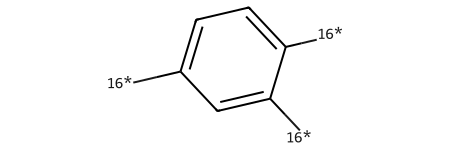

In [4]:
# load the fragments from the database and show a random fragment
with open('RPIS_BRICS_Fragment_DB.smi', 'r') as database:
    brics_fragment_smiles = [line.rstrip('\n') for line in database]
    
brics_fragments = [Chem.MolFromSmiles(smiles) for smiles in brics_fragment_smiles]
brics_fragments[np.random.randint(len(brics_fragments))]

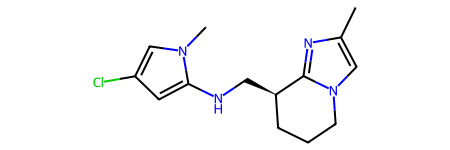

In [5]:
# Build random molecule from the BRICS fragments (up to 'maxDepth' fragments are used)
for mol in BRICS.BRICSBuild(brics_fragments,        # The fragment pool from which to build
                            maxDepth=5,             # The maximum number of fragments to use 
                            onlyCompleteMols=True,  # No open bonds left
                            uniquify=True,          # If generating a library only retain unique canonical SMILES
                            scrambleReagents=True,  # if False the same molecule is retained every time
                            seeds=None,):           # an optional list of seed molecules to use as starting points.
    break    # IF THE BREAK IS REMOVED ALL POSSIBLE FRAGMENTS WILL BE GENERATED (IN THE ORDER OF 4e11, TAKES WAY TOO LONG)
mol          # show the molecule in IPython environment

In [6]:
outputDirectory = './'
singleSMIoutput = f'{outputDirectory}/brics_{datetime.datetime.now():%Y-%m-%d_%H-%M-%S}.smi'

with open(singleSMIoutput, 'w') as outputFile:
    outputFile.write(Chem.MolToSmiles(mol))

Draw.MolToFile(mol, singleSMIoutput.replace('smi','png'), size=(300, 300))